In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [3]:
data_dir = "../data/ROUND1/"
def prices_day(n): return f"prices_round_1_day_{n}.csv"
def trades_day(n): return f"trades_round_0_day_{n}.csv"


In [74]:
n = "-2"
price_df = pd.read_csv(data_dir + prices_day(n), delimiter=";")
price_df['product'].unique()

<ArrowStringArray>
['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']
Length: 2, dtype: str

In [75]:
def plot_product_analysis(df, product_name, window=20, detrend=True, remove_zeros=True, use_ma_detrend=True):
    # 1. Filter Data
    query = df["product"] == product_name
    if remove_zeros:
        query &= df['mid_price'] > 0
    
    y = df[query]['mid_price'].values
    x = np.arange(len(y))
    
    if len(y) < window:
        print(f"Not enough data for {product_name}")
        return

    # 2. Calculate GLOBAL Trend (Only for the Title/Label)
    # This is a "future leak" if used for trading, but fine for a post-hoc title.
    slope, intercept = np.polyfit(x, y, 1)

    # 3. Calculate Trailing Moving Average (LEAK-FREE)
    ma_series = pd.Series(y).rolling(window=window)
    ma = ma_series.mean()

    # 4. Process Detrending
    label_suffix = "Original"
    plot_data = y
    
    if detrend:
        if use_ma_detrend:
            # LEAK-FREE: Subtracting only past/present info
            plot_data = y - ma.values
            label_suffix = "MA-Detrended (Trailing)"
        else:
            # LEAK: signal.detrend uses the entire series (Global)
            plot_data = signal.detrend(y) 
            label_suffix = "Linear-Detrended (Global)"

    # 5. Stats - Handling NaNs from the trailing window
    valid_mask = ~np.isnan(plot_data)
    clean_data = plot_data[valid_mask]
    
    # Check if we have data left after windowing
    if len(clean_data) == 0:
        return None

    pct_above = (np.sum(clean_data > 0) / len(clean_data)) * 100
    pct_below = (np.sum(clean_data < 0) / len(clean_data)) * 100

    # 6. Plotting
    plt.figure(figsize=(12, 6))
    
    # Plot main series (using x[valid_mask] to align if needed, but plotting all is fine for visual)
    plt.plot(plot_data, label=f"{label_suffix} Price", alpha=0.7, color='steelblue' if not detrend else 'gray')
    
    if detrend:
        plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
        plt.fill_between(x, plot_data, 0, where=(plot_data > 0), color='green', alpha=0.15)
        plt.fill_between(x, plot_data, 0, where=(plot_data < 0), color='red', alpha=0.15)
        plt.ylabel("Deviation from Trend")
    else:
        plt.plot(ma.values, label=f"{window}-Period MA", color='darkorange', linewidth=2)
        plt.ylabel("Price")

    plt.title(f"{product_name} ({label_suffix})\n"
              f"Linear Trend: y = {slope:.4f}x + {intercept:.2f} | Above: {pct_above:.1f}% Below: {pct_below:.1f}%")
    
    plt.xlabel("Time (Observations)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.2)
    plt.show()

    return {"slope": slope, "intercept": intercept, "pct_above": pct_above, "pct_below": pct_below}

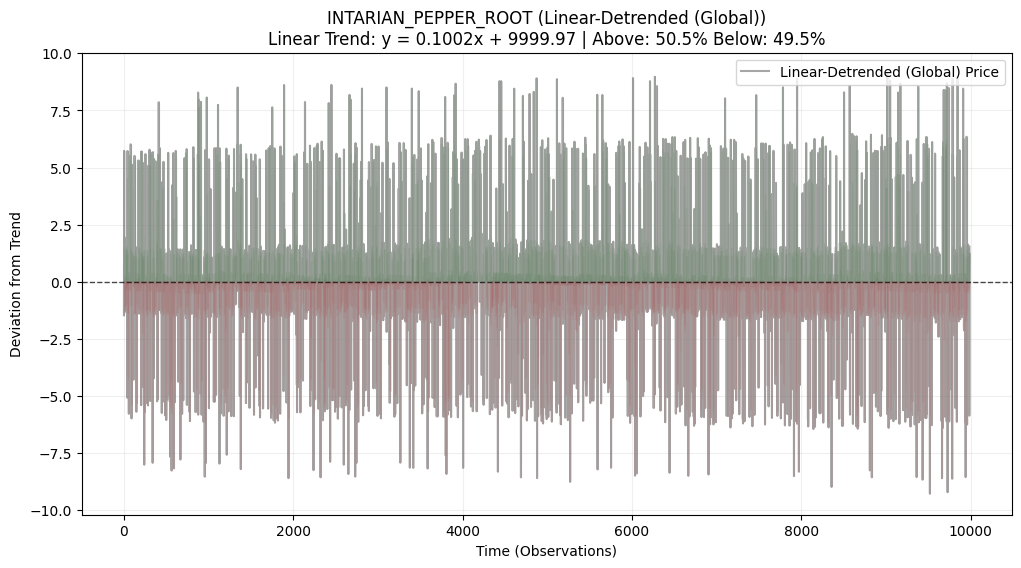

{'slope': np.float64(0.1001692005234352),
 'intercept': np.float64(9999.968977253939),
 'pct_above': np.float64(50.510817307692314),
 'pct_below': np.float64(49.48918269230769)}

In [76]:
prod_name = "INTARIAN_PEPPER_ROOT"

plot_product_analysis(price_df, prod_name, use_ma_detrend=False, detrend=True)

In [77]:
price_df[price_df['product'] == prod_name]

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0
7,-2,300,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,10006.0,10.0,10008.0,21.0,NaN,NaN,10006.0,0.0
9,-2,400,INTARIAN_PEPPER_ROOT,9992.0,20.0,NaN,NaN,NaN,NaN,10006.0,12.0,10008.0,20.0,NaN,NaN,9999.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19991,-2,999500,INTARIAN_PEPPER_ROOT,10991.0,20.0,NaN,NaN,NaN,NaN,11008.0,20.0,NaN,NaN,NaN,NaN,10999.5,0.0
19993,-2,999600,INTARIAN_PEPPER_ROOT,10994.0,9.0,NaN,NaN,NaN,NaN,11006.0,9.0,NaN,NaN,NaN,NaN,11000.0,0.0
19994,-2,999700,INTARIAN_PEPPER_ROOT,10994.0,10.0,10991.0,18.0,NaN,NaN,11008.0,18.0,NaN,NaN,NaN,NaN,11001.0,0.0
19996,-2,999800,INTARIAN_PEPPER_ROOT,10994.0,11.0,10991.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10994.0,0.0


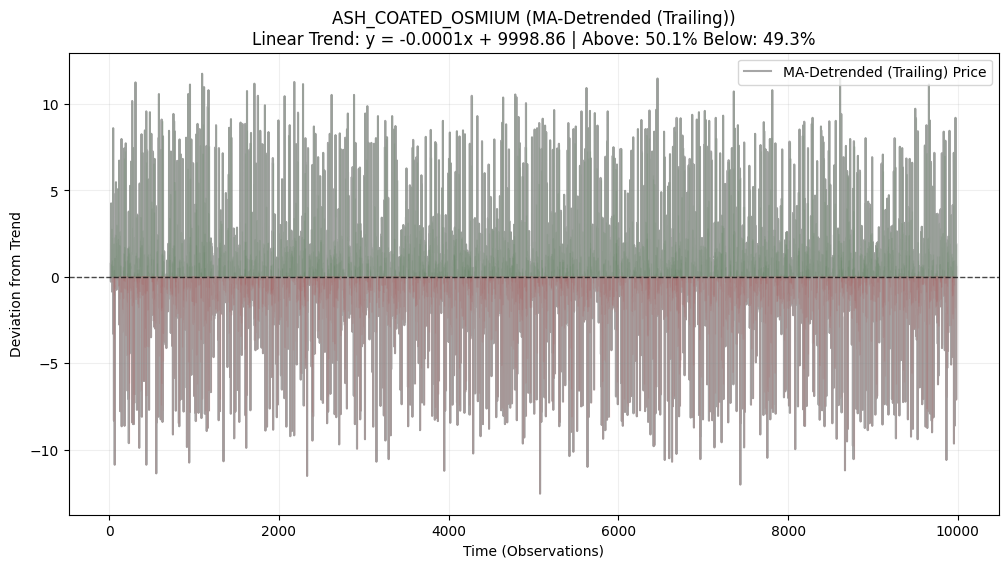

{'slope': np.float64(-0.00013912477971729),
 'intercept': np.float64(9998.864208043673),
 'pct_above': np.float64(50.05520425574627),
 'pct_below': np.float64(49.27230753789019)}

In [78]:
prod_name = "ASH_COATED_OSMIUM"
plot_product_analysis(price_df, prod_name, use_ma_detrend=True, detrend=True)

In [ ]:
def plot_advanced_analysis(df, product_name, window=20, lag=1, remove_zeros=True):
    # 1. Filter Data
    query = df["product"] == product_name
    if remove_zeros:
        query &= df['mid_price'] > 0
    
    data = df[query].copy()
    y = data['mid_price']
    
    if len(y) < window + lag:
        print(f"Not enough data for {product_name}")
        return

    # 2. Calculate Rolling Z-Score
    # Uses a trailing window to avoid future leaks
    rolling_mean = y.rolling(window=window).mean()
    rolling_std = y.rolling(window=window).std()
    z_score = (y - rolling_mean) / rolling_std

    # 3. Calculate Rolling Autocorrelation (Lag 1)
    # This correlates the price with its own shifted version over the window
    returns = y.diff().dropna()
    rolling_autocorr = returns.rolling(window=window).corr(returns.shift(lag))

    # 4. Plotting
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    # --- Panel 1: Price and MA ---
    axes[0].plot(y.values, label='Mid Price', color='steelblue', alpha=0.8)
    axes[0].plot(rolling_mean.values, label=f'{window}-Period MA', color='darkorange', linewidth=1.5)
    axes[0].set_title(f"{product_name}: Price & Moving Average")
    axes[0].set_ylabel("Price")
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.2)
    
    # --- Panel 2: Rolling Z-Score ---
    axes[1].plot(z_score.values, label='Z-Score', color='purple')
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
    # Statistical Thresholds
    axes[1].axhline(2, color='red', linestyle=':', alpha=0.7, label='Overbought (2σ)')
    axes[1].axhline(-2, color='red', linestyle=':', alpha=0.7, label='Oversold (-2σ)')
    axes[1].fill_between(range(len(z_score)), z_score, 2, where=(z_score > 2), color='red', alpha=0.2)
    axes[1].fill_between(range(len(z_score)), z_score, -2, where=(z_score < -2), color='red', alpha=0.2)
    axes[1].set_title(f"Rolling Z-Score ({window} Window)")
    axes[1].set_ylabel("Std Devs from Mean")
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.2)
    
    # --- Panel 3: Rolling Autocorrelation ---
    axes[2].plot(rolling_autocorr.values, label=f'Autocorr (Lag {lag})', color='teal')
    axes[2].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[2].set_title(f"Rolling Autocorrelation (Momentum vs. Mean-Reversion)")
    axes[2].set_xlabel("Time (Observations)")
    axes[2].set_ylabel("Correlation Coefficient")
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig('advanced_product_analysis.png')
    plt.show()

    return z_score, rolling_autocorr

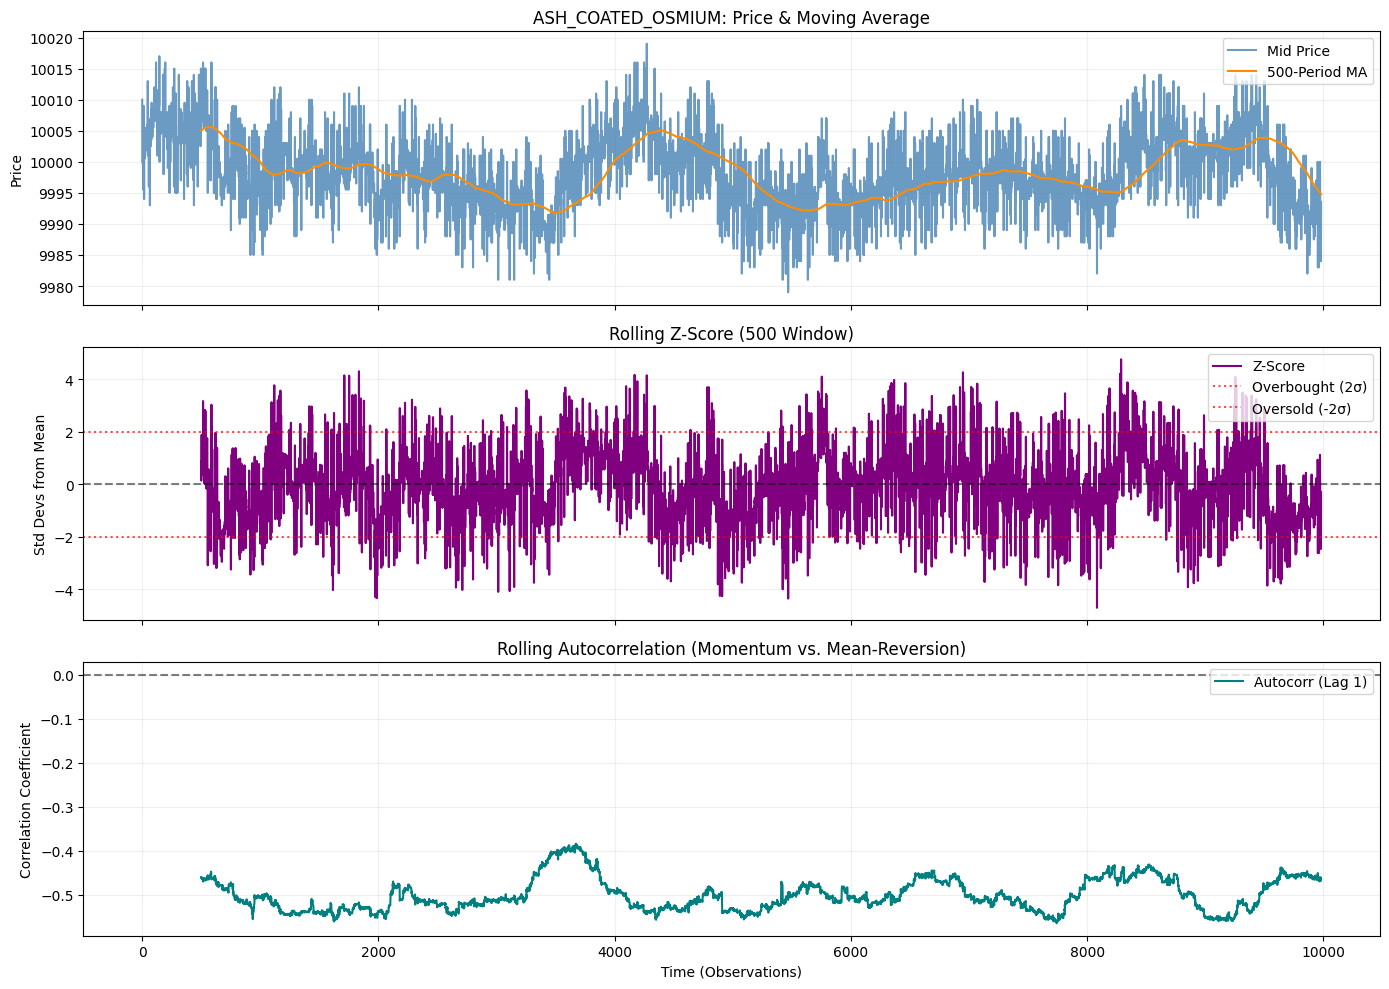

(1             NaN
 3             NaN
 5             NaN
 6             NaN
 8             NaN
            ...   
 19990   -0.651636
 19992   -0.648593
 19995   -0.645554
 19997   -2.462476
 19999   -0.289729
 Name: mid_price, Length: 9982, dtype: float64,
 3             NaN
 5             NaN
 6             NaN
 8             NaN
 11            NaN
            ...   
 19990   -0.462789
 19992   -0.462647
 19995   -0.462785
 19997   -0.460458
 19999   -0.467012
 Name: mid_price, Length: 9981, dtype: float64)

In [85]:
plot_advanced_analysis(price_df, prod_name, window=500)